In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
import pickle
import nue_booster
import importlib
importlib.reload(nue_booster)
import awkward
from typing import List, Tuple, Any, Union
from numpy.typing import NDArray
import hashlib
import logging
import os
import yaml
from numu_tki import selection_1muNp 
from numu_tki import signal_1muNp 
from numu_tki import tki_calculators 

import localSettings as ls

import sys, os 
from data_loading import load_runs

from microfit.selections import get_selection_query

In [3]:
# Load in samples
# RUN = ["5_nuepresel"]
RUN = ["4a_nuepresel","4b_nuepresel","4c_nuepresel","4d_nuepresel","5_nuepresel"]
# RUN = ["4a_nuepresel_testsplit","4b_nuepresel_testsplit","4c_nuepresel_testsplit","4d_nuepresel_testsplit","5_nuepresel_testsplit"]
# RUN = ["4a_nuepresel_testsplit"]
# RUN = ["4a", "4b", "4c", "4d", "5"]
# RUN = ["5_nuepresel"]
rundata, mc_weights, data_pot = load_runs(
    RUN,
    data="bnb",
    truth_filtered_sets=["nue", "drt", "nc_pi0"],
    use_truth_filters=False,
    loadpi0variables=True,
    loadshowervariables=True, # Loads in all variables we might want, including BDT variables (use_bdt=True asserts that these variables are loaded)
    loadrecoveryvars=True,
    loadsystematics=False,    # Set to false when we don't have event weights
    load_crt_vars=True,
    loadnumuvariables=True,
    use_bdt = False,          # Set use_BDT to false since we are training the BDT here, not using it
    use_numi=False,
    load_lee=False,
    enable_cache=True,
    blinded=True,             # Set blinded to true, no training on data!!
)

# Same loading settings as test_bdt.ipynb
# rundata, mc_weights, data_pot = load_runs(
#     RUN,
#     data="bnb",
#     truth_filtered_sets=["nue", "drt", "nc_pi0"],
#     use_truth_filters=False,
#     loadpi0variables=True,
#     loadshowervariables=True,
#     loadrecoveryvars=True,
#     loadsystematics=False,    # Set to false when we don't have event weights
#     load_crt_vars=True,
#     use_bdt = True,
#     load_lee=False,
#     enable_cache=True,
#     blinded=True,
# )

Loading run 4a_nuepresel
Loading run 4b_nuepresel
Loading run 4c_nuepresel
Loading run 4d_nuepresel
Loading run 5_nuepresel


In [4]:
df_nu=rundata["mc"]
df_nue=rundata["nue"]
df_dirt=rundata["drt"]
df_ncpi0=rundata["nc_pi0"]
df_ext=rundata["ext"]

In [5]:
import pandas as pd

pd.set_option('display.max_rows', None)

print(df_nu["nu_pdg"])

0        14
1        14
2        14
3        14
4        14
5        14
6        14
7        14
8        14
9        14
10       14
11       12
12       14
13       14
14       14
15       14
16       14
17       14
18       14
19       14
20       14
21       14
22       14
23       14
24       14
25       14
26       14
27       14
28       14
29       12
30       14
31       14
32       14
33       14
34       14
35       14
36       14
37       14
38       14
39       14
40       14
41       14
42       14
43       14
44       14
45       14
46       14
47       14
48       14
49       14
50       14
51       12
52       14
53       14
54       14
55       14
56       14
57       14
58       14
59       14
60       14
61       14
62       14
63       14
64       14
65       14
66       14
67       14
68       14
69       14
70       14
71       14
72       14
73       14
74       14
75       14
76       14
77       14
78       14
79       14
80       14
81       14
82       14
83  

In [6]:
# print(df_nue["is_signal"])
# print(df_nue["category"])
# print(df_nu)

In [ ]:
# Split dataframes into training and testing samples
# train_nu, test_nu = train_test_split(df_nu, test_size=0.5, random_state=1990)
# train_nue_truth, test_nue = train_test_split(df_nue, test_size=0.5, random_state=1990)
train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
train_ncpi0_truth, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

In [ ]:
# Separate CC Nue events from nu overlay
NUEQUERY = '(abs(nu_pdg)==12 & ccnc==0)'
nu_ccnue = df_nu.query(NUEQUERY)

# Separate NC Pi0 events from nu overlay
NCPI0QUERY = '(mcf_pass_ncpi0==1)'
nu_ncpi0 = df_nu.query(NCPI0QUERY)

# Get sample that doesn't have CC Nue or NC Pi0 events (basically take the opposite of the previous two queries combined)
MCQUERY = '((abs(nu_pdg)==12 & ccnc==0) | mcf_pass_ncpi0==1)'
nu_no_ccnue_ncpi0 = df_nu.query('~'+MCQUERY)

# Split this new nu overlay sample into training and testing samples
train_nu, test_nu = train_test_split(nu_no_ccnue_ncpi0, test_size=0.5, random_state=1990)

# Add the nu overlay NC pi0 events to the NC pi0 training sample
train_ncpi0 = pd.concat([train_ncpi0_truth, nu_ncpi0], ignore_index=True)

In [ ]:
nue_signal = 'ZP'
# nue_signal = 'ZP_NP'
# nue_signal = 'ALL'

ZPQUERY = 'category==10'
NPQUERY = 'category==11'
NUEOTHERQUERY = '(category!=10 & category!=11)'

# Split nue overlay into three different nue categories
zp_nue = df_nue.query(ZPQUERY)
np_nue = df_nue.query(NPQUERY)
other_nue = df_nue.query(NUEOTHERQUERY)

# Split nu overlay CC nue samples into different nue categories 
zp_nu_ccnue = nu_ccnue.query(ZPQUERY)
np_nu_ccnue = nu_ccnue.query(NPQUERY)
other_nu_ccnue = nu_ccnue.query(NUEOTHERQUERY)

if nue_signal == 'ZP':
    # Define signal and background nue samples
    signal_nue = zp_nue
    bkg_nue = pd.concat([np_nue, other_nue], ignore_index=True)

    # Define signal and background nue events from nu overlay sample
    signal_nu_ccnue = zp_nu_ccnue
    bkg_nu_ccnue = pd.concat([np_nu_ccnue, other_nu_ccnue], ignore_index=True)

    # Split signal and background nue samples
    train_signal_df_nue, test_signal_nue = train_test_split(signal_nue, test_size=0.5, random_state=1990)
    train_bkg_df_nue, test_bkg_nue = train_test_split(bkg_nue, test_size=0.5, random_state=1990)

    # Concatenate nu overlay CC nue events into their respective nue overlay training samples
    train_signal_nue = pd.concat([train_signal_df_nue, signal_nu_ccnue], ignore_index=True)
    train_bkg_nue = pd.concat([train_bkg_df_nue, bkg_nu_ccnue], ignore_index=True)

if nue_signal == 'ZP_NP':
    signal_nue = pd.concat([zp_nue, np_nue], ignore_index=True)
    bkg_nue = other_nue

    signal_nu_ccnue = pd.concat([zp_nu_ccnue, np_nu_ccnue])
    bkg_nu_ccnue = other_nu_ccnue

    # Split signal and background nue samples
    train_signal_df_nue, test_signal_nue = train_test_split(signal_nue, test_size=0.5, random_state=1990)
    train_bkg_df_nue, test_bkg_nue = train_test_split(bkg_nue, test_size=0.5, random_state=1990)

    # Concatenate nu overlay CC nue events into their respective nue overlay training samples
    train_signal_nue = pd.concat([train_signal_df_nue, signal_nu_ccnue], ignore_index=True)
    train_bkg_nue = pd.concat([train_bkg_df_nue, bkg_nu_ccnue], ignore_index=True)

if nue_signal == 'ALL':
    train_nue_truth, test_nue = train_test_split(df_nue, test_size = 0.5)
    train_nue = pd.concat([train_nue_truth, nu_ccnue])

In [1]:
# print(nu_ccnue["nu_pdg"])

# print(nu_ncpi0["nu_pdg"])

# print(train_nu["nu_pdg"])

In [10]:
# train_nu_25p, test_nu_25p = train_test_split(test_nu, test_size = 0.5, random_state=1990)
# train_nue_25p, test_nue_25p = train_test_split(test_nue, test_size = 0.5, random_state=1990)
# train_dirt_25p, test_dirt_25p = train_test_split(test_dirt, test_size = 0.5, random_state=1990)
# train_ncpi0_25p, test_ncpi0_25p = train_test_split(test_ncpi0, test_size = 0.5, random_state=1990)
# train_ext_25p, test_ext_25p = train_test_split(test_ext, test_size = 0.5, random_state=1990)

In [11]:
# test_nue.to_csv(os.path.join("/exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/bdt", "run45_train_nue.csv"), index=False)

In [ ]:
if nue_signal == 'ZP' or nue_signal == 'ZP_NP':
    samples = {
        "mc": (train_nu, test_nu),
        "nue_signal": (train_signal_nue, test_signal_nue),
        "nue_bkg": (train_bkg_nue, test_bkg_nue),
        "dirt": (train_dirt, test_dirt),
        "ncpi0": (train_ncpi0, test_ncpi0),
        "ext": (train_ext, test_ext),
    }

if nue_signal == 'ALL':
    samples = {
        "mc": (train_nu, test_nu),
        "nue": (train_nue, test_nue),
        "dirt": (train_dirt, test_dirt),
        "ncpi0": (train_ncpi0, test_ncpi0),
        "ext": (train_ext, test_ext),
    }

# samples = {
#     "mc": (train_nu_25p, test_nu_25p),
#     "nue": (train_nue_25p, test_nue_25p),
#     "dirt": (train_dirt_25p, test_dirt_25p),
#     "ncpi0": (train_ncpi0_25p, test_ncpi0_25p),
#     "ext": (train_ext_25p, test_ext_25p),
# }

In [13]:
# Set weights for training samples
for k, df in samples.items():
    df[0].loc[:,"train_weight"] = 1.
    df[1].loc[:,"train_weight"] = 1.

# override here train_weight for specific samples, if needed
# QUESTION: are there more specific weights we need here?
samples['ext'][0].loc[:,"train_weight"] = 10.
samples['ext'][1].loc[:,"train_weight"] = 10.

# Set train weight for a specific category (find out what category 4 is)
for k, df in samples.items():
    df[0].loc[df[0]['category']==4,"train_weight"] = 10.
    df[1].loc[df[1]['category']==4,"train_weight"] = 10.

# set train_weight based on reco_e binning
# reco_bins = np.linspace(0.15,1.55,15)
# #reco_scaling = [8,5,3,3,2,2,2,1,1,1,1,1,1,1]
# reco_scaling = [1,1,1,1,1,1,1,1,1,1,1,1,1,1]
# for k, df in samples.items():
#     for i, reco_bin in enumerate(reco_bins):
#         if i == 0: continue
#         df[0].loc[(df[0]['reco_e'] > reco_bins[i-1]) & (df[0]['reco_e'] < reco_bins[i]), 'train_weight'] = df[0]['train_weight']*reco_scaling[i-1]

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`


In [14]:
# variables to be trained on
# TRAINVAR = ["shr_score","tksh_distance","tksh_angle",
#             "shr_tkfit_dedx_max",
#             "trkfit","trkpid",
#             "subcluster","shrmoliereavg",
#             "trkshrhitdist2","hits_ratio",
#             "secondshower_Y_nhit","secondshower_Y_vtxdist","secondshower_Y_dot","anglediff_Y",
#             "CosmicIPAll3D","CosmicDirAll3D",
#             "is_signal","train_weight","nu_e"]

# Second Shower Variables
# TRAINVAR = ["secondshower_U_nhit",
#         "secondshower_U_vtxdist",
#         "secondshower_U_dot",
#         "secondshower_U_dir",
#         "anglediff_U",
#         "secondshower_V_nhit",
#         "secondshower_V_vtxdist",
#         "secondshower_V_dot",
#         "secondshower_V_dir",
#         "anglediff_V",
#         "secondshower_Y_nhit",
#         "secondshower_Y_vtxdist",
#         "secondshower_Y_dot",
#         "secondshower_Y_dir",
#         "anglediff_Y",
#         "is_signal","train_weight","nu_e"
# ]

# dE/dx and Pi0 Variables
# TRAINVAR = [
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "is_signal","train_weight","nu_e"
# ]

# Inclusive set of variables
# TRAINVAR = [
#     "shrmoliereavg",
#     "shr_score",
#     "trkfit",
#     "subcluster",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "shrMCSMom",
#     "DeltaRMS2h",
#     "shrPCA1CMed_5cm",
#     "CylFrac2h_1cm",    
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "is_signal","train_weight","nu_e"
# ]

# Inclusive set of variables w/ NuGraph
# TRAINVAR = [
#     "shrmoliereavg",
#     "shr_score",
#     "trkfit",
#     "subcluster",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "shrMCSMom",
#     "DeltaRMS2h",
#     "shrPCA1CMed_5cm",
#     "CylFrac2h_1cm",    
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "slcng2mip",
#     "slcng2hip",
#     "slcng2shr",
#     "slcng2mcl",
#     "slcng2dfs",
#     "slcng2bkg",
#     "clung2mip",
#     "clung2hip",
#     "clung2shr",
#     "clung2mcl",
#     "clung2dfs",
#     "clung2bkg",
#     "nhits_r1cm",
#     "nhits_r3cm",
#     "nhits_r5cm",
#     "nhits_r10cm",
#     "diffY","normdiffY","diffZ","normdiffZ","fnl",
#     "is_signal","train_weight","nu_e"
# ]

TRAINVAR = [
    "shrmoliereavg",
    "shr_score",
    "trkfit",
    "subcluster",
    "CosmicIPAll3D",
    "CosmicDirAll3D",
    "shrMCSMom",
    "DeltaRMS2h",
    "shrPCA1CMed_5cm",
    "CylFrac2h_1cm",    
    "shr_tkfit_2cm_dedx_Y",
    "shr_tkfit_2cm_dedx_U",
    "shr_tkfit_2cm_dedx_V",
    "shr_tkfit_gap10_dedx_Y",
    "shr_tkfit_gap10_dedx_U",
    "shr_tkfit_gap10_dedx_V",
    # "shr_tkfit_dedx_U",
    # "shr_tkfit_dedx_V",
    # "shr_tkfit_dedx_Y",
    "shr_tkfit_dedx_max",
    "secondshower_U_nhit",
    "secondshower_U_vtxdist",
    "secondshower_U_dot",
    "secondshower_U_dir",
    "anglediff_U",
    "secondshower_V_nhit",
    "secondshower_V_vtxdist",
    "secondshower_V_dot",
    "secondshower_V_dir",
    "anglediff_V",
    "secondshower_Y_nhit",
    "secondshower_Y_vtxdist",
    "secondshower_Y_dot",
    "secondshower_Y_dir",
    "anglediff_Y",
    "slcng2mip",
    "slcng2hip",
    "slcng2shr",
    "slcng2mcl",
    "slcng2dfs",
    "slcng2bkg",
    "clung2mip",
    "clung2hip",
    "clung2shr",
    "clung2mcl",
    "clung2dfs",
    "clung2bkg",
    "nhits_r1cm",
    "nhits_r3cm",
    "nhits_r5cm",
    "nhits_r10cm",
    "diffY","normdiffY","diffZ","normdiffZ","fnl",
    "is_signal","train_weight","nu_e"
]

# Np Training Variables
# TRAINVAR = [
#     "shr_score",
#     "tksh_distance",
#     "tksh_angle",
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "trkfit",
#     "trkpid",
#     "subcluster",
#     "shrmoliereavg",
#     "trkshrhitdist2",
#     "hits_ratio",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "slcng2mip",
#     "slcng2hip",
#     "slcng2shr",
#     "slcng2mcl",
#     "slcng2dfs",
#     "slcng2bkg",
#     "clung2mip",
#     "clung2hip",
#     "clung2shr",
#     "clung2mcl",
#     "clung2dfs",
#     "clung2bkg",
#     "nhits_r1cm",
#     "nhits_r3cm",
#     "nhits_r5cm",
#     "nhits_r10cm",
#     "diffY","normdiffY","diffZ","normdiffZ","fnl",
#     "is_signal","train_weight","nu_e"
# ]

In [15]:
# print (ls.pickle_path)

XGBoost params. ETA: 0.02, MAX_DEPTH: 3, SUBSAMPLE: 0.8, COLSAMPLE_BY_TREE: 1
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl', 'is_signa

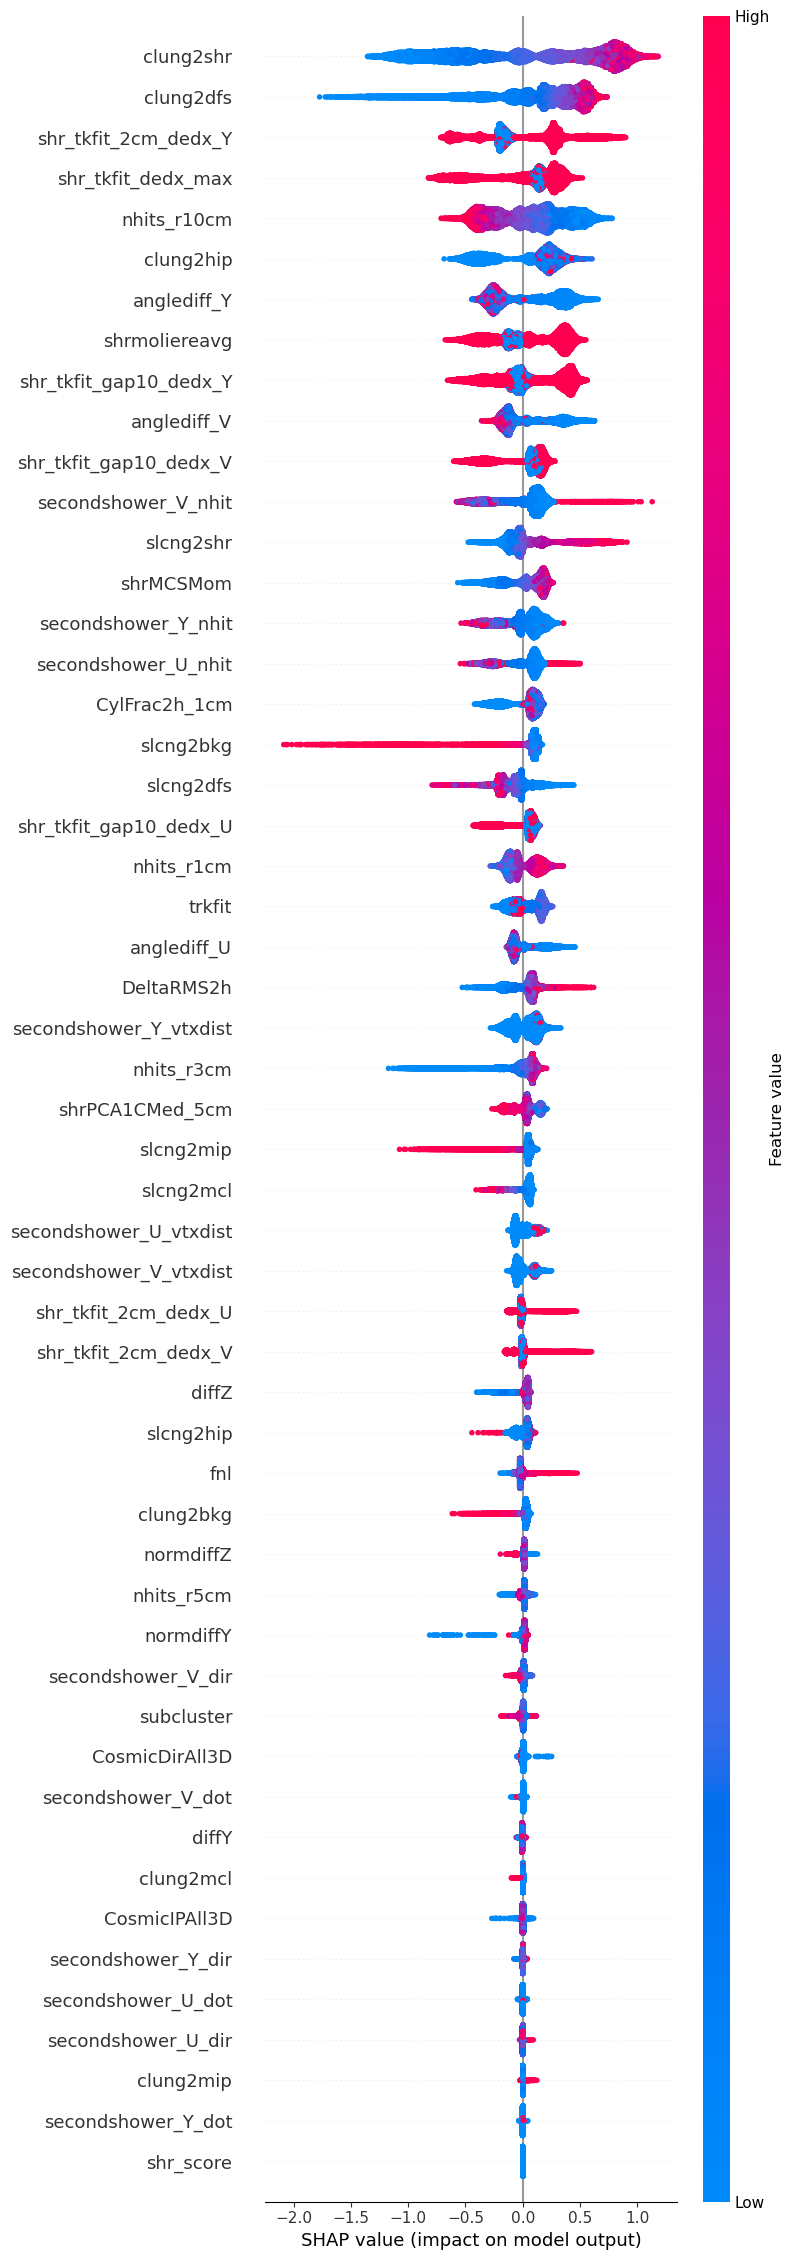

area under the precision-recall curve: 0.975831
precision score: 0.913915
recall score: 0.925568
Importance (total_gain):
clung2shr 138555.66991260988
shr_tkfit_dedx_max 37653.16093844999
anglediff_Y 37601.68093331597
shr_tkfit_2cm_dedx_Y 37378.54600758004
shr_tkfit_gap10_dedx_Y 32771.65402656998
slcng2bkg 32488.262270000014
clung2hip 31800.6394677
clung2dfs 30616.87824709
shrmoliereavg 23376.950580309993
nhits_r10cm 21676.921076749983
secondshower_V_nhit 19057.26777666001
secondshower_Y_nhit 16783.528420900013
shrMCSMom 15481.684019249993
anglediff_V 14738.182233489993
secondshower_U_nhit 12907.714796160008
shr_tkfit_gap10_dedx_V 12197.880131020005
slcng2shr 10678.191783510003
slcng2mip 9925.070657099996
slcng2dfs 8076.158036466995
CylFrac2h_1cm 7272.092810710003
secondshower_Y_vtxdist 7038.076363998997
DeltaRMS2h 6471.745752300004
anglediff_U 6461.547016180001
nhits_r3cm 6174.520221078004
trkfit 5765.360850919999
shr_tkfit_gap10_dedx_U 5302.9379280719995
nhits_r1cm 4966.19413439
slcn

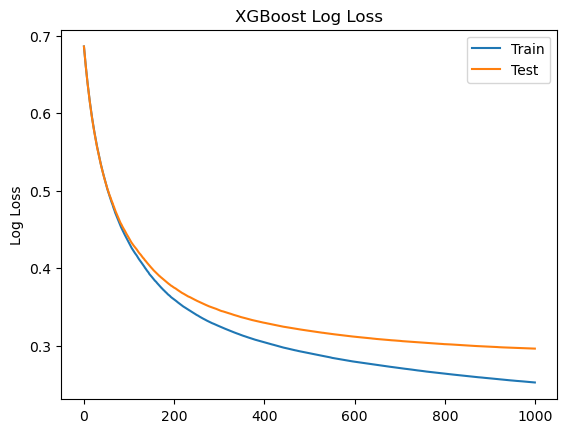

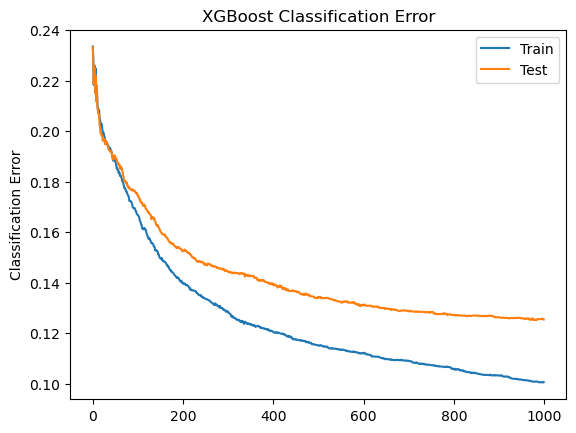

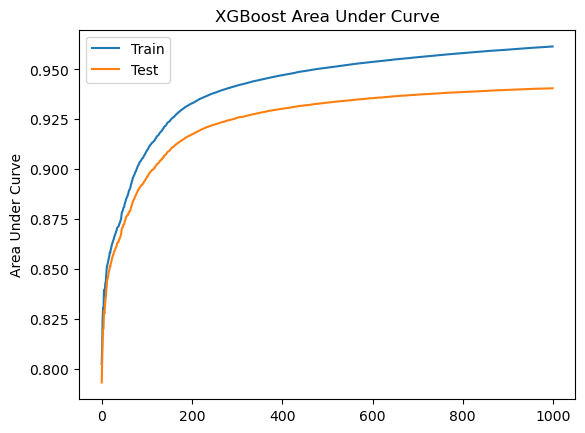

Training pi0...
&category!=10 and category!=11 and npi0>0
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl']
Validating...


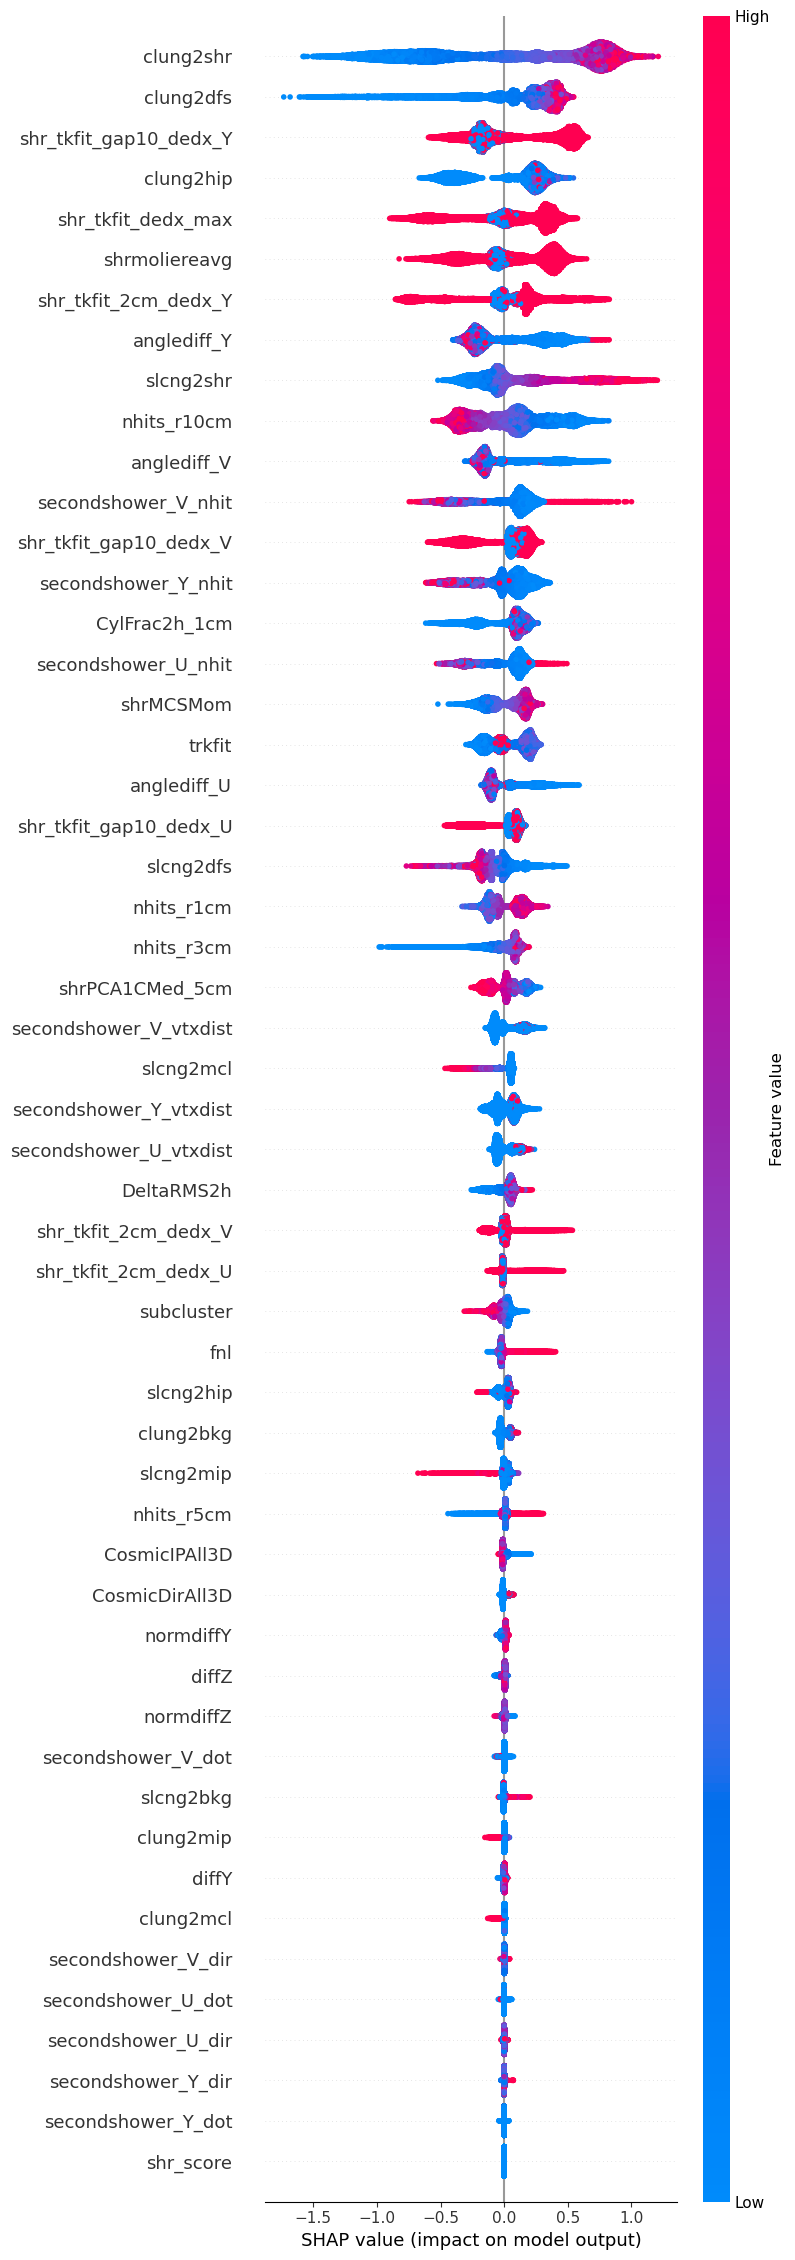

area under the precision-recall curve: 0.978667
precision score: 0.915467
recall score: 0.936840
Importance (total_gain):
clung2shr 129101.60899241001
shr_tkfit_dedx_max 42228.76281945896
shr_tkfit_gap10_dedx_Y 40219.06940506999
clung2hip 31542.18308803
shr_tkfit_2cm_dedx_Y 28825.284494969983
anglediff_Y 27128.597442957016
secondshower_V_nhit 22163.924949610013
shrmoliereavg 21241.21242321002
clung2dfs 19855.062791450026
anglediff_V 17426.92100589001
secondshower_Y_nhit 17093.679726534
slcng2shr 15607.067435359997
secondshower_U_nhit 12769.829251139996
nhits_r10cm 11819.459790773006
shr_tkfit_gap10_dedx_V 11334.273773370007
shrMCSMom 9765.802590750005
CylFrac2h_1cm 9516.766172320007
slcng2dfs 7778.991333430001
anglediff_U 7525.312986780002
trkfit 5658.598238040001
nhits_r3cm 5075.570938500004
shr_tkfit_gap10_dedx_U 4716.690465080001
nhits_r1cm 4474.206882005
secondshower_V_vtxdist 3620.1462024459997
secondshower_Y_vtxdist 3352.1986254200015
shr_tkfit_2cm_dedx_V 3234.053055160001
shrPCA

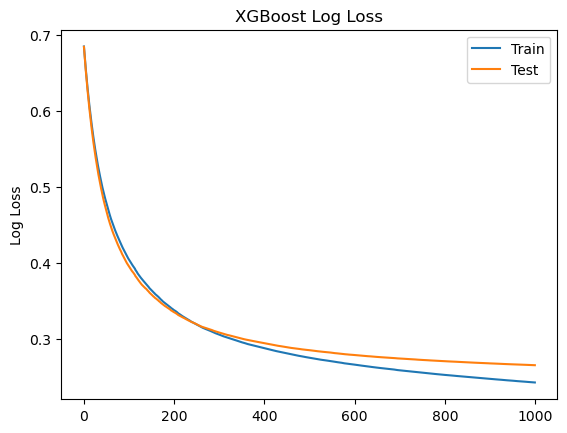

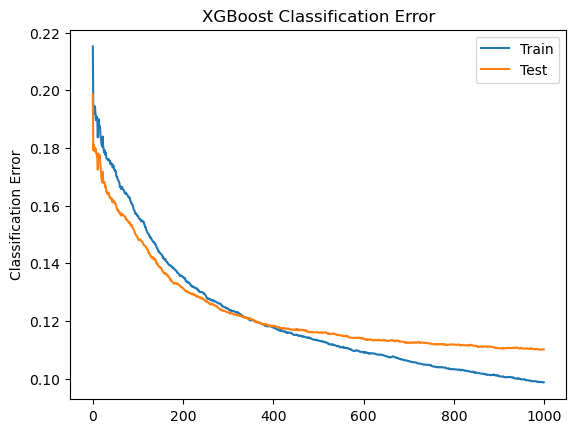

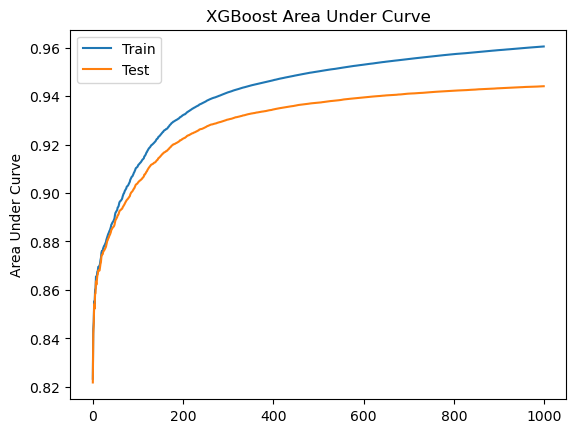

Training nonpi0...
&category!=10 and category!=11 and npi0==0
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl']
Validating...


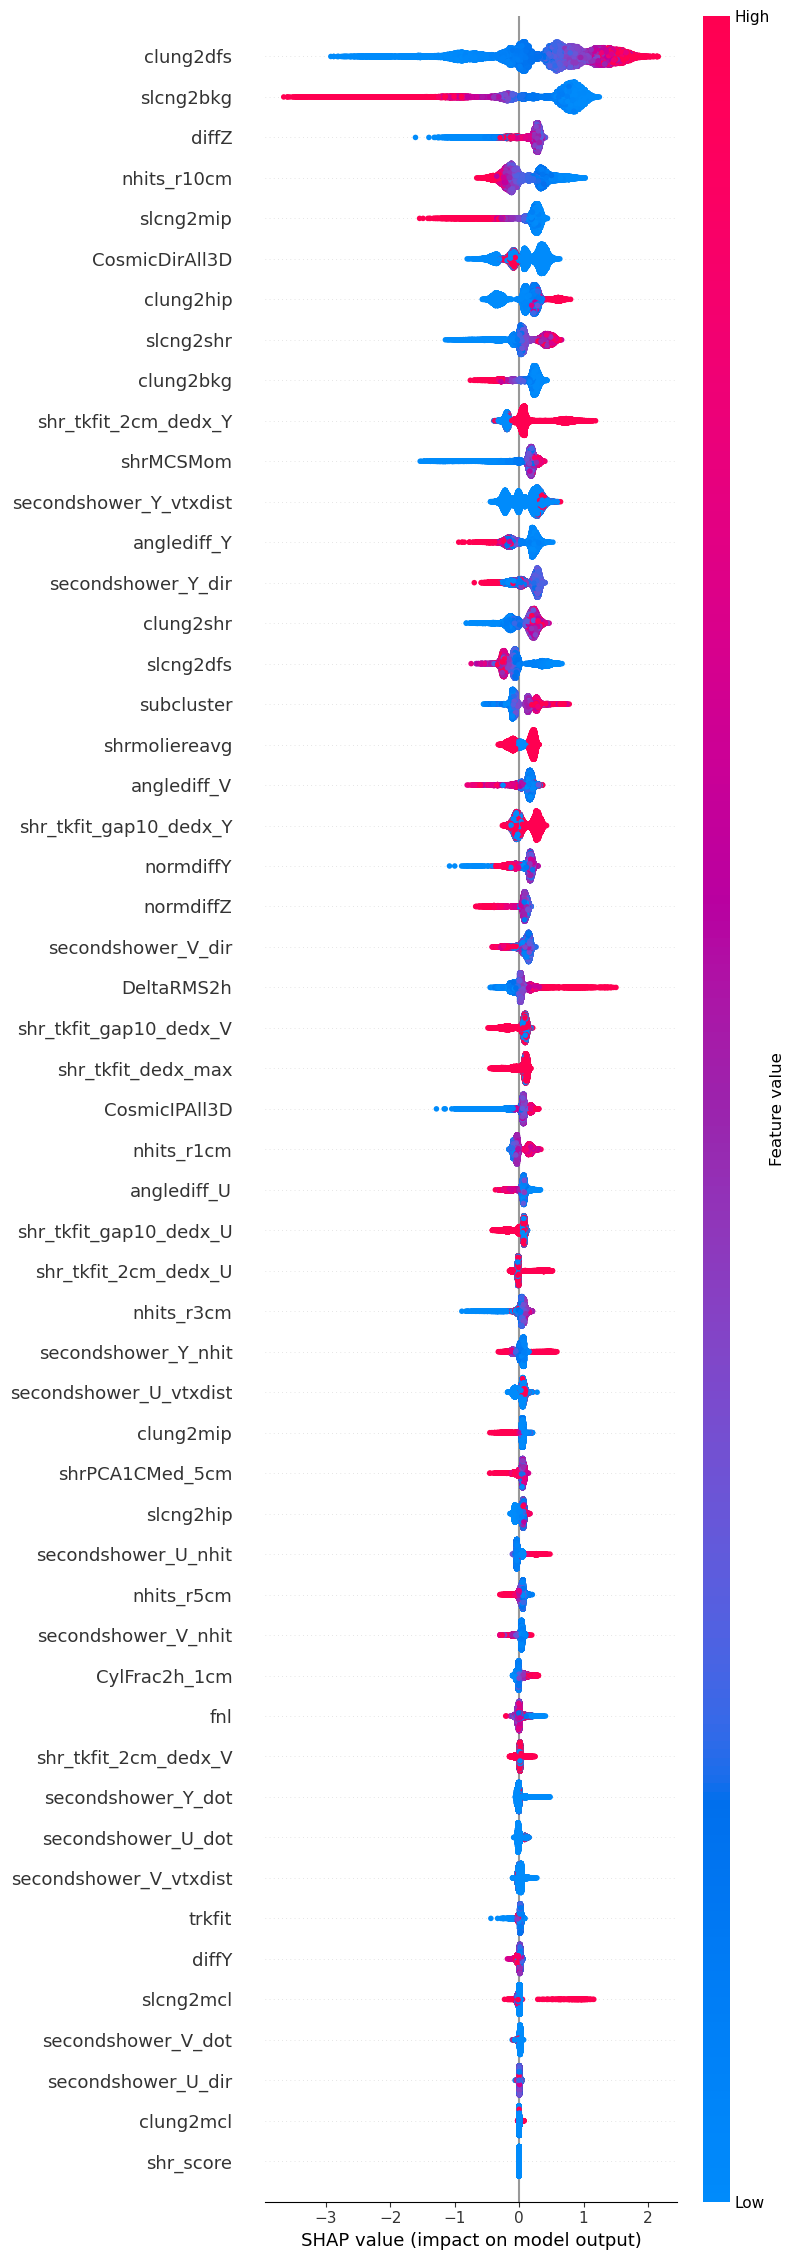

area under the precision-recall curve: 0.999337
precision score: 0.989334
recall score: 0.994723
Importance (total_gain):
slcng2bkg 91746.996837757
clung2dfs 32297.2032673356
anglediff_Y 14581.265327409004
clung2shr 12602.46203444201
shrMCSMom 12558.888373722308
subcluster 11103.860834137036
slcng2shr 10979.652435536
diffZ 10802.370402547296
CosmicDirAll3D 10735.944913734007
secondshower_Y_vtxdist 9338.783526168
clung2bkg 9256.505861390002
slcng2mip 9234.1101549766
nhits_r10cm 8473.790261888495
secondshower_V_dir 8396.341043428
shr_tkfit_2cm_dedx_Y 7699.4992537000035
DeltaRMS2h 7477.476176798011
anglediff_V 7430.823662813996
secondshower_Y_dir 6065.562339049001
CosmicIPAll3D 5482.302152450998
clung2hip 5023.411987492
normdiffY 3919.155100129999
shr_tkfit_gap10_dedx_Y 3658.7397841435004
normdiffZ 3520.5349861662
clung2mip 3213.0682524600006
shrmoliereavg 2977.891329899999
shr_tkfit_dedx_max 2977.749473766001
anglediff_U 2936.3575416040017
shr_tkfit_gap10_dedx_V 2897.1359491740004
nhits_

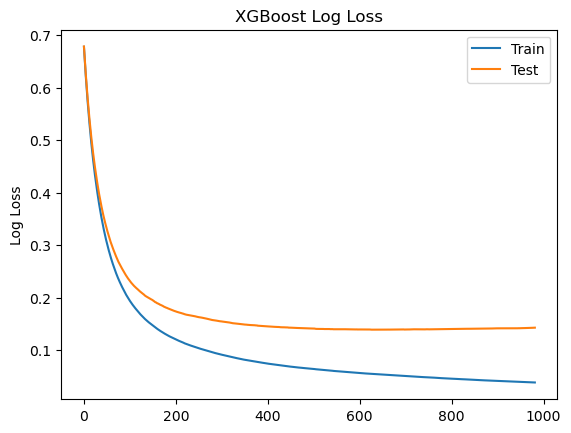

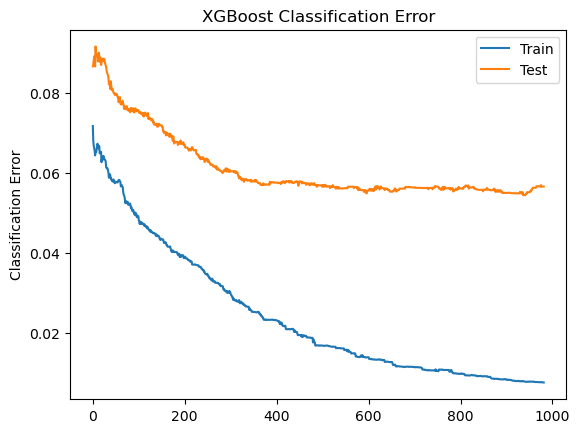

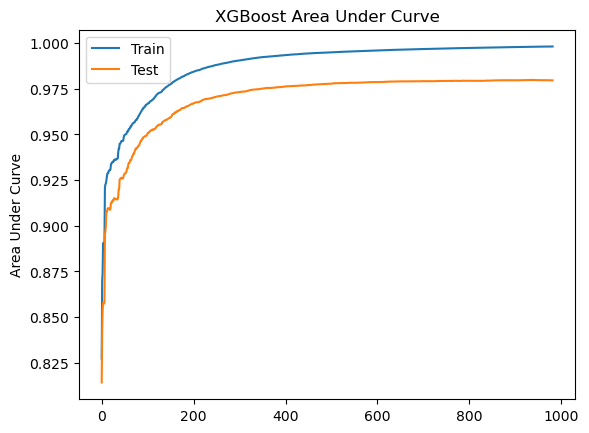

In [16]:
fig, ax = plt.subplots(1,1)

importlib.reload(nue_booster)
my_booster = nue_booster.NueBooster(samples, TRAINVAR, random_state=1990)

print (my_booster.variables)

# Nue Preselection
# PRESEL = 'slice_orig_pass_id == 1'
# PRESEL += ' and n_showers_contained == 1'
# PRESEL += ' and contained_fraction > 0.9'
# PRESEL += ' and shr_energy_tot_cali > 0.07'
# PRESEL += ' and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'

# Extra Cosmic Rejection
# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and trkfit < 0.65'

PRESEL = '( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'
PRESEL += ' and n_tracks_contained == 0'

PRESEL += ' and crtveto != 1'

PRESEL += ' and CosmicIPAll3D > 10.'
PRESEL += ' and shrmoliereavg < 20'
PRESEL += ' and subcluster > 5'
PRESEL += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 100'
PRESEL += ' and shr_trk_len > 20'
PRESEL += ' and CylFrac2h_1cm < 0.7'
PRESEL += ' and shrMCSMom > 20'
PRESEL += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'

PRESEL += ' and diffZ > -70 and diffZ < 80'
PRESEL += ' and normdiffZ > -0.75 and normdiffZ < 0.75'
PRESEL += ' and fnl > -200 and fnl < 50'

# PRESEL += ' and nonpi0_score > 0.9'
# PRESEL += ' and pi0_score > 0.5'

# PRESEL += ' and slcng2hip < 40'
# PRESEL += ' and slcng2mip < 50'
# PRESEL += ' and slcng2mcl < 40'
# PRESEL += ' and clung2hip < 50'

# Old Loose Sel.
# PRESEL = '( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'
# PRESEL += ' and n_tracks_contained == 0'
# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and CosmicDirAll3D > -0.9 and CosmicDirAll3D < 0.9'
# PRESEL += ' and shrmoliereavg < 15'
# PRESEL += ' and subcluster > 4'
# PRESEL += ' and trkfit < 0.65'
# PRESEL += ' and secondshower_Y_nhit < 50'
# PRESEL += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 80'
# PRESEL += ' and shr_trk_sce_end_y > -100 and shr_trk_sce_end_y < 100 '
# PRESEL += ' and shr_trk_len < 300.'
# PRESEL += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'

my_booster.set_preselection(PRESEL)

gain_imp = {}

for label, bkg_query in zip(nue_booster.labels, nue_booster.bkg_queries):
    
    preds, gain_imp[label], evals_result, shap_values = my_booster.train_booster(ax, bkg_query)
    
    with open(ls.pickle_path+'booster_%s_45_1011_0pnewloosesel_query50split.pickle' % label, 'wb') as booster_file:
        pickle.dump(preds, booster_file)

    #print(evals_result)
    epochs = len(evals_result['train']['error'])
    x_axis = range(0, epochs)
    # plot log loss
    fig1, ax1 = plt.subplots()
    ax1.plot(x_axis, evals_result['train']['logloss'], label='Train')
    ax1.plot(x_axis, evals_result['eval']['logloss'], label='Test')
    ax1.legend()
    plt.ylabel('Log Loss')
    plt.title('XGBoost Log Loss')
    plt.show()
    # plot classification error
    fig2, ax2 = plt.subplots()
    ax2.plot(x_axis, evals_result['train']['error'], label='Train')
    ax2.plot(x_axis, evals_result['eval']['error'], label='Test')
    ax2.legend()
    plt.ylabel('Classification Error')
    plt.title('XGBoost Classification Error')
    plt.show()
    # plot auc
    fig3, ax3 = plt.subplots()
    ax3.plot(x_axis, evals_result['train']['auc'], label='Train')
    ax3.plot(x_axis, evals_result['eval']['auc'], label='Test')
    ax3.legend()
    plt.ylabel('Area Under Curve')
    plt.title('XGBoost Area Under Curve')
    plt.show()

    
ax.set_ylim([0, 1.05])
ax.set_xlim([0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC')
ax.legend()
fig.tight_layout()
#fig.savefig(ls.plots_path+"roc_single.pdf")

In [17]:
print('mc',train_nu.query(PRESEL)["train_weight"].sum())
print('nue',train_nue.query(PRESEL)["train_weight"].sum())
print('dirt',train_dirt.query(PRESEL)["train_weight"].sum())
print('ncpi0',train_ncpi0.query(PRESEL)["train_weight"].sum())
print('ext',train_ext.query(PRESEL)["train_weight"].sum())

# print('mc',train_nu_25p.query(PRESEL)["train_weight"].sum())
# print('nue',train_nue_25p.query(PRESEL)["train_weight"].sum())
# print('dirt',train_dirt_25p.query(PRESEL)["train_weight"].sum())
# print('ncpi0',train_ncpi0_25p.query(PRESEL)["train_weight"].sum())
# print('ext',train_ext_25p.query(PRESEL)["train_weight"].sum())

mc 708.0
nue 30496.0
dirt 29.0
ncpi0 10288.0
ext 2600.0


In [18]:
print('mc',test_nu.query(PRESEL)["train_weight"].sum())
print('nue',test_nue.query(PRESEL)["train_weight"].sum())
print('dirt',test_dirt.query(PRESEL)["train_weight"].sum())
print('ncpi0',test_ncpi0.query(PRESEL)["train_weight"].sum())
print('ext',test_ext.query(PRESEL)["train_weight"].sum())

# print('mc',test_nu_25p.query(PRESEL)["train_weight"].sum())
# print('nue',test_nue_25p.query(PRESEL)["train_weight"].sum())
# print('dirt',test_dirt_25p.query(PRESEL)["train_weight"].sum())
# print('ncpi0',test_ncpi0_25p.query(PRESEL)["train_weight"].sum())
# print('ext',test_ext_25p.query(PRESEL)["train_weight"].sum())

mc 699.0
nue 30254.0
dirt 22.0
ncpi0 8046.0
ext 3320.0


{'clung2shr': 129101.60899241001, 'secondshower_V_nhit': 22163.924949610013, 'shr_tkfit_dedx_max': 42228.76281945896, 'anglediff_V': 17426.92100589001, 'shr_tkfit_gap10_dedx_Y': 40219.06940506999, 'secondshower_Y_nhit': 17093.679726534, 'anglediff_Y': 27128.597442957016, 'clung2hip': 31542.18308803, 'shr_tkfit_2cm_dedx_Y': 28825.284494969983, 'shrmoliereavg': 21241.21242321002, 'shr_tkfit_gap10_dedx_V': 11334.273773370007, 'slcng2shr': 15607.067435359997, 'secondshower_U_nhit': 12769.829251139996, 'CylFrac2h_1cm': 9516.766172320007, 'clung2dfs': 19855.062791450026, 'nhits_r10cm': 11819.459790773006, 'anglediff_U': 7525.312986780002, 'shrMCSMom': 9765.802590750005, 'trkfit': 5658.598238040001, 'slcng2dfs': 7778.991333430001, 'nhits_r1cm': 4474.206882005, 'shr_tkfit_gap10_dedx_U': 4716.690465080001, 'slcng2mip': 1746.9385557500004, 'fnl': 1619.8949045100003, 'slcng2hip': 1474.8064703099994, 'clung2mip': 479.08201638, 'secondshower_V_dir': 222.78869972, 'slcng2mcl': 3141.7572667000013, 's

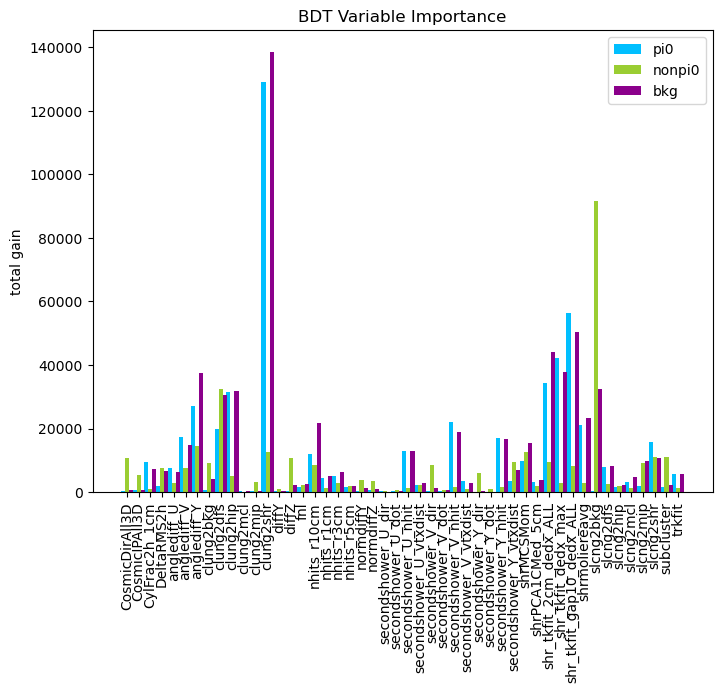

In [19]:
print(gain_imp['pi0'])
print(gain_imp['nonpi0'])
print(gain_imp['bkg'])

if 'shr_tkfit_gap10_dedx_V' in gain_imp['pi0']:
    gain_imp['pi0']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['pi0']['shr_tkfit_gap10_dedx_V']+gain_imp['pi0']['shr_tkfit_gap10_dedx_U']+gain_imp['pi0']['shr_tkfit_gap10_dedx_Y']
    gain_imp['nonpi0']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['nonpi0']['shr_tkfit_gap10_dedx_V']+gain_imp['nonpi0']['shr_tkfit_gap10_dedx_U']+gain_imp['nonpi0']['shr_tkfit_gap10_dedx_Y']
    gain_imp['bkg']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['bkg']['shr_tkfit_gap10_dedx_V']+gain_imp['bkg']['shr_tkfit_gap10_dedx_U']+gain_imp['bkg']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_V']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_U']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_V']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_U']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_V']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_U']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_Y']
if 'shr_tkfit_2cm_dedx_V' in gain_imp['pi0']:
    gain_imp['pi0']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['pi0']['shr_tkfit_2cm_dedx_V']+gain_imp['pi0']['shr_tkfit_2cm_dedx_U']+gain_imp['pi0']['shr_tkfit_2cm_dedx_Y']
    gain_imp['nonpi0']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['nonpi0']['shr_tkfit_2cm_dedx_V']+gain_imp['nonpi0']['shr_tkfit_2cm_dedx_U']+gain_imp['nonpi0']['shr_tkfit_2cm_dedx_Y']
    gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['bkg']['shr_tkfit_2cm_dedx_V']+gain_imp['bkg']['shr_tkfit_2cm_dedx_U']+gain_imp['bkg']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_V']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_U']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_V']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_U']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_V']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_U']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_Y']

print(gain_imp['bkg'])
# print(gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'])

labels = []
pi0_imp = []
nonpi0_imp = []
bkg_imp = []

for i in sorted (gain_imp['pi0'].keys()) :  
    labels.append(i)
    pi0_imp.append(gain_imp['pi0'][i])
    nonpi0_imp.append(gain_imp['nonpi0'][i])
    bkg_imp.append(gain_imp['bkg'][i])
    
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, pi0_imp, width, label='pi0', color='deepskyblue')
rects2 = ax.bar(x, nonpi0_imp, width, label='nonpi0', color='yellowgreen')
rects3 = ax.bar(x + width, bkg_imp, width, label='bkg', color='darkmagenta')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('total gain')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_gain.pdf")
#fig.savefig(ls.plots_path+"bdt_var_gain.pdf")

In [20]:
# print(gain_imp['np'])

# if 'shr_tkfit_gap10_dedx_V' in gain_imp['np']:
#     gain_imp['np']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['np']['shr_tkfit_gap10_dedx_V']+gain_imp['np']['shr_tkfit_gap10_dedx_U']+gain_imp['np']['shr_tkfit_gap10_dedx_Y']
#     del gain_imp['np']['shr_tkfit_gap10_dedx_V']
#     del gain_imp['np']['shr_tkfit_gap10_dedx_U']
#     del gain_imp['np']['shr_tkfit_gap10_dedx_Y']
# if 'shr_tkfit_2cm_dedx_V' in gain_imp['np']:
#     gain_imp['np']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['np']['shr_tkfit_2cm_dedx_V']+gain_imp['np']['shr_tkfit_2cm_dedx_U']+gain_imp['np']['shr_tkfit_2cm_dedx_Y']
#     del gain_imp['np']['shr_tkfit_2cm_dedx_V']

# print(gain_imp['np'])
# # print(gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'])

# labels = []
# np_imp = []

# for i in sorted (gain_imp['np'].keys()) :  
#     labels.append(i)
#     np_imp.append(gain_imp['np'][i])
    
# x = np.arange(len(labels))  # the label locations
# width = 0.4  # the width of the bars

# fig, ax = plt.subplots(figsize=(8,6))
# rects2 = ax.bar(x, np_imp, width, label='np', color='mediumvioletred')

# # Add some text for labels, title and custom x-axis tick labels, etc.
# ax.set_ylabel('total gain')
# ax.set_title('BDT Variable Importance')
# ax.set_xticks(x)
# ax.set_xticklabels(labels, rotation = 90)
# ax.legend()

# plt.show()
# fig.tight_layout()
# #fig.savefig(ls.plots_path+"0109/bdt_var_gain.pdf")
# #fig.savefig(ls.plots_path+"bdt_var_gain.pdf")

{'clung2shr': 48, 'shr_tkfit_gap10_dedx_ALL': 47, 'shr_tkfit_dedx_max': 46, 'shr_tkfit_2cm_dedx_ALL': 45, 'clung2hip': 44, 'anglediff_Y': 43, 'secondshower_V_nhit': 42, 'shrmoliereavg': 41, 'clung2dfs': 40, 'anglediff_V': 39, 'secondshower_Y_nhit': 38, 'slcng2shr': 37, 'secondshower_U_nhit': 36, 'nhits_r10cm': 35, 'shrMCSMom': 34, 'CylFrac2h_1cm': 33, 'slcng2dfs': 32, 'anglediff_U': 31, 'trkfit': 30, 'nhits_r3cm': 29, 'nhits_r1cm': 28, 'secondshower_V_vtxdist': 27, 'secondshower_Y_vtxdist': 26, 'shrPCA1CMed_5cm': 25, 'slcng2mcl': 24, 'secondshower_U_vtxdist': 23, 'DeltaRMS2h': 22, 'slcng2mip': 21, 'fnl': 20, 'nhits_r5cm': 19, 'subcluster': 18, 'slcng2hip': 17, 'clung2bkg': 16, 'normdiffZ': 15, 'CosmicIPAll3D': 14, 'clung2mip': 13, 'slcng2bkg': 12, 'secondshower_V_dot': 11, 'diffZ': 10, 'normdiffY': 9, 'CosmicDirAll3D': 8, 'clung2mcl': 7, 'diffY': 6, 'secondshower_V_dir': 5, 'secondshower_U_dir': 4, 'secondshower_U_dot': 3, 'secondshower_Y_dir': 2, 'secondshower_Y_dot': 1}
{'slcng2bkg':

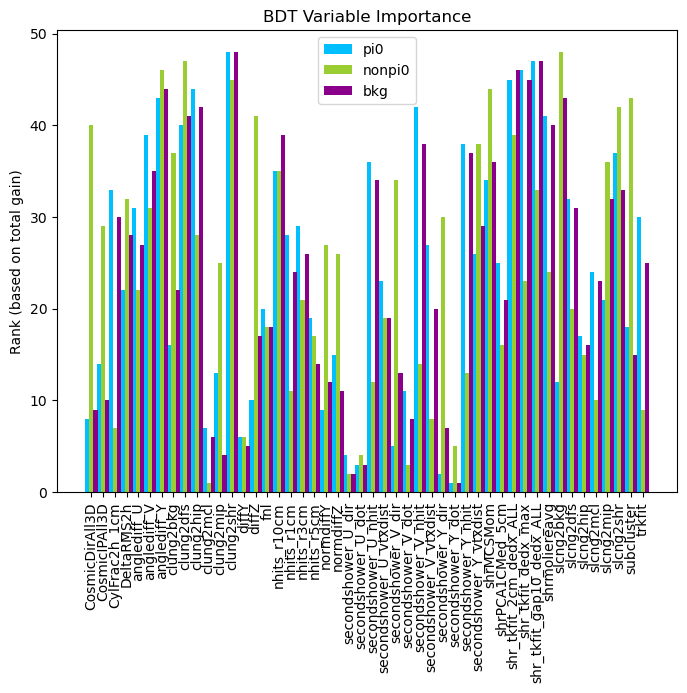

In [21]:
d_pi0_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['pi0'], key=gain_imp['pi0'].get, reverse=True):
    d_pi0_rnk[w] = rnk
    rnk = rnk-1
print(d_pi0_rnk)

d_nonpi0_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['nonpi0'], key=gain_imp['nonpi0'].get, reverse=True):
    d_nonpi0_rnk[w] = rnk
    rnk = rnk-1
print(d_nonpi0_rnk)

d_bkg_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['bkg'], key=gain_imp['bkg'].get, reverse=True):
    d_bkg_rnk[w] = rnk
    rnk = rnk-1
print(d_bkg_rnk)

pi0_rnk = []
nonpi0_rnk = []
bkg_rnk = []

for i in labels:  
    pi0_rnk.append(d_pi0_rnk[i])
    nonpi0_rnk.append(d_nonpi0_rnk[i])
    bkg_rnk.append(d_bkg_rnk[i])
    
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, pi0_rnk, width, label='pi0', color='deepskyblue')
rects2 = ax.bar(x, nonpi0_rnk, width, label='nonpi0', color='yellowgreen')
rects3 = ax.bar(x + width, bkg_rnk, width, label='bkg', color='darkmagenta')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Rank (based on total gain)')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_rank.pdf")
#fig.savefig(ls.plots_path+"bdt_var_rank.pdf")

In [22]:
# d_np_rnk = {}
# rnk = len(labels)
# for w in sorted(gain_imp['np'], key=gain_imp['np'].get, reverse=True):
#     d_np_rnk[w] = rnk
#     rnk = rnk-1
# print(d_np_rnk)

# np_rnk = []

# for i in labels:  
#     np_rnk.append(d_np_rnk[i])
    
# x = np.arange(len(labels))  # the label locations
# width = 0.4  # the width of the bars

# fig, ax = plt.subplots(figsize=(8,6))
# rects1 = ax.bar(x - width, np_rnk, width, label='np', color='cornflowerblue')

# # Add some text for labels, title and custom x-axis tick labels, etc.
# ax.set_ylabel('Rank (based on total gain)')
# ax.set_title('BDT Variable Importance')
# ax.set_xticks(x)
# ax.set_xticklabels(labels, rotation = 90)
# ax.legend()

# plt.show()
# fig.tight_layout()
# #fig.savefig(ls.plots_path+"0109/bdt_var_rank.pdf")
# #fig.savefig(ls.plots_path+"bdt_var_rank.pdf")